In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
notes = pd.read_csv("data/train/train_notes.csv")
tab = pd.read_csv("data/train/train_tabular.csv", usecols=["flight_id", "failure_within_horizon", "drone_id"])
full = pd.merge( left = notes, right = tab, on = "flight_id", how = "inner")

<Axes: title={'center': 'Failure'}>

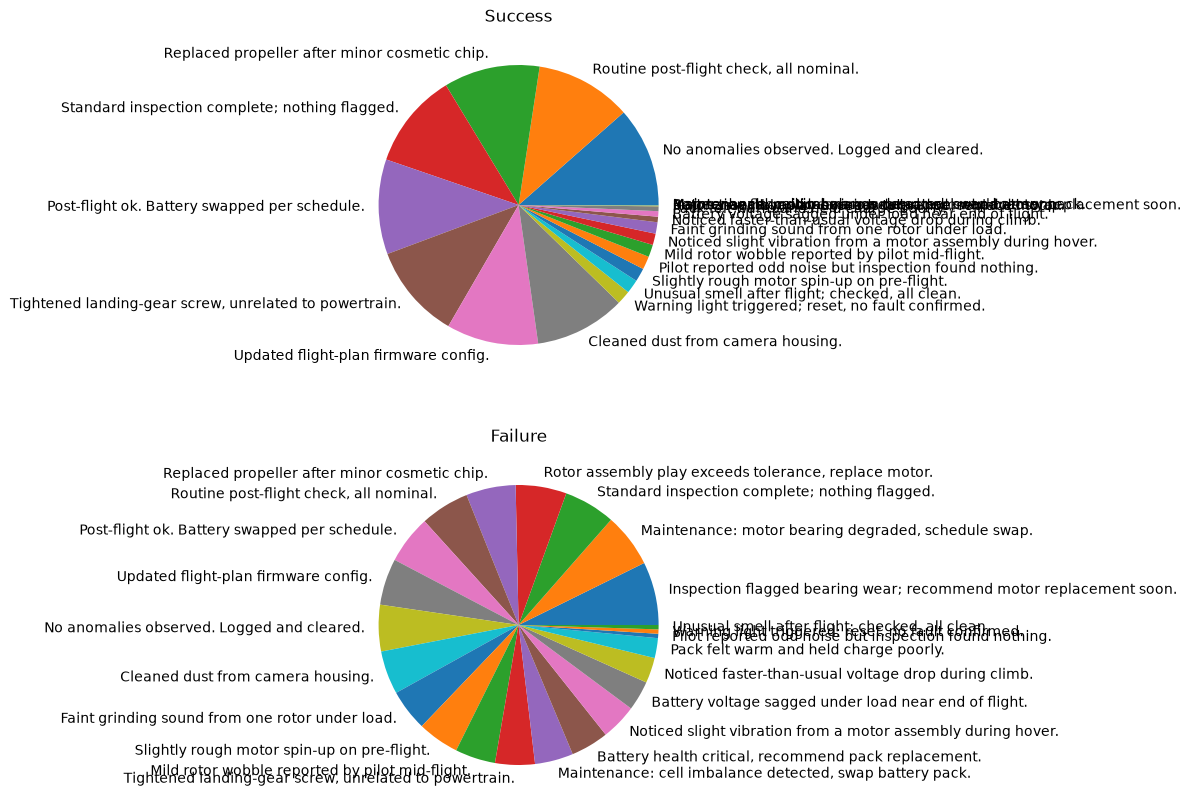

In [4]:
_, axes = plt.subplots(2, 1, figsize=[10, 10])
full[full.failure_within_horizon == 0].maintenance_note.value_counts().plot.pie(ax = axes[0], title="Success")
full[full.failure_within_horizon == 1].maintenance_note.value_counts().plot.pie(ax = axes[1], title = "Failure")

In [5]:
full.groupby("maintenance_note").failure_within_horizon.mean().sort_values()

maintenance_note
Warning light triggered; reset, no fault confirmed.                   0.041667
Unusual smell after flight; checked, all clean.                       0.042169
Pilot reported odd noise but inspection found nothing.                0.043750
Tightened landing-gear screw, unrelated to powertrain.                0.055030
No anomalies observed. Logged and cleared.                            0.061025
Cleaned dust from camera housing.                                     0.062444
Updated flight-plan firmware config.                                  0.065847
Post-flight ok. Battery swapped per schedule.                         0.066214
Routine post-flight check, all nominal.                               0.066220
Replaced propeller after minor cosmetic chip.                         0.067058
Standard inspection complete; nothing flagged.                        0.069631
Slightly rough motor spin-up on pre-flight.                           0.300448
Noticed slight vibration from a mot

In [6]:
failure_rates = (
    full.groupby('maintenance_note')['failure_within_horizon']
    .agg(['mean', 'count'])
    .query('count > 20')
    .assign(failure_rate=lambda x: x['mean'] * 100)
    .sort_values('mean')
    .reset_index()
)

In [7]:
failure_rates

,maintenance_note,mean,count,failure_rate
0,"Warning light triggered; reset, no fault confi...",0.041667,168,4.166667
1,"Unusual smell after flight; checked, all clean.",0.042169,166,4.216867
2,Pilot reported odd noise but inspection found ...,0.043750,160,4.375000
3,"Tightened landing-gear screw, unrelated to pow...",0.055030,1163,5.503009
4,No anomalies observed. Logged and cleared.,0.061025,1229,6.102522
5,Cleaned dust from camera housing.,0.062444,1121,6.244425
6,Updated flight-plan firmware config.,0.065847,1139,6.584723
7,Post-flight ok. Battery swapped per schedule.,0.066214,1178,6.621392
8,"Routine post-flight check, all nominal.",0.066220,1193,6.621961
9,Replaced propeller after minor cosmetic chip.,0.067058,1193,6.705784


In [8]:
for zone in ['routine', 'early_warning', 'critical']:
    print(f"\n--- {zone} ---")
    subset = failure_rates[failure_rates['zone'] == zone][['maintenance_note', 'failure_rate', 'count']]
    print(subset.to_string(index=False))


--- routine ---


KeyError: 'zone'

In [ ]:
failure_rates['zone'] = pd.cut(
    failure_rates['mean'],
    bins=[0, 0.07, 0.50, 1.0],
    labels=['routine', 'early_warning', 'critical']
)

In [ ]:
import plotly.express as px

px.bar(failure_rates, x='failure_rate', y='maintenance_note', 
       color='zone', orientation='h',
       color_discrete_map={
           'routine': '#1baf7a',
           'early_warning': '#eda100',
           'critical': '#e34948'
       })

In [ ]:
test = pd.read_csv("data/test/test_notes.csv")

In [ ]:
test.maintenance_note.value_counts()

maintenance_note
Cleaned dust from camera housing.                                     609
Replaced propeller after minor cosmetic chip.                         595
No anomalies observed. Logged and cleared.                            560
Standard inspection complete; nothing flagged.                        543
Tightened landing-gear screw, unrelated to powertrain.                540
Updated flight-plan firmware config.                                  530
Routine post-flight check, all nominal.                               525
Post-flight ok. Battery swapped per schedule.                         521
Slightly rough motor spin-up on pre-flight.                           118
Noticed slight vibration from a motor assembly during hover.          112
Faint grinding sound from one rotor under load.                       103
Mild rotor wobble reported by pilot mid-flight.                        94
Unusual smell after flight; checked, all clean.                        80
Pilot reported odd no

In [ ]:
failure_rates = (
    full.groupby('maintenance_note')['failure_within_horizon']
    .agg(['mean', 'count'])
    .query('count > 20')
    .assign(failure_rate=lambda x: x['mean'] * 100)
    .sort_values('mean')
    .reset_index()
)

NameError: name 'full' is not defined